# Japan Population Analysis

In this project, I analyze population data of Japan across different prefectures.

The goal is to understand how population is distributed and apply statistical concepts such as mean, median, and measures of spread on real-world data.

This project builds on basic statistical concepts and applies them to a real dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset

The dataset is loaded using pandas. It contains population data categorized by prefecture, age group, gender, and year.

In [2]:
df = pd.read_csv("data/japanese_census.csv")
df.head()

,Unnamed: 0,Year,Prefecture,Age Lower Bound,Age Upper Bound,Gender,Population
0,0,1920,Hokkaido,0,4.0,Male,190044
1,1,1920,Hokkaido,0,4.0,Female,186632
2,2,1920,Hokkaido,5,9.0,Male,161814
3,3,1920,Hokkaido,5,9.0,Female,157556
4,4,1920,Hokkaido,10,14.0,Male,138018


## Understanding the Dataset

Before analysis, it is important to understand the structure of the data, including available columns.

In [3]:
df.columns

Index(['Unnamed: 0', 'Year', 'Prefecture', 'Age Lower Bound',
       'Age Upper Bound', 'Gender', 'Population'],
      dtype='str')

##  Data Cleaning

The dataset contains unnecessary columns and multiple breakdowns such as age, gender, year. 

To make the data usable:
- Remove unnecessary columns  
- Filter data for the latest year  
- Aggregate population for each prefecture  

In [4]:
df = pd.read_csv("data/japanese_census.csv")
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df = df[df['Year'] == df['Year'].max()]
df['Prefecture'] = df['Prefecture'].replace(
    'Tokyo Metropolis',
    'Tokyo Prefecture'
)
df_grouped = df.groupby('Prefecture')['Population'].sum().reset_index()
df_grouped.head()

,Prefecture,Population
0,Aichi Prefecture,7401952
1,Akita Prefecture,1014579
2,Aomori Prefecture,1297015
3,Chiba Prefecture,6126343
4,Ehime Prefecture,1362407


### Note on Dataset

The dataset contains 46 administrative regions instead of the expected 47 prefectures of Japan.

This may be due to how the dataset categorizes regions. The analysis will proceed using the available data.

### Exploratory Data Analysis

Before applying statistical measures, it is important to explore the cleaned dataset and understand its structure, size, and quality.

In [5]:
df_grouped.shape 

(46, 2)

Data has 46 prefectures and 2 columns.

In [6]:
df_grouped.dtypes 

Prefecture      str
Population    int64
dtype: object

The dataset contains:
- Prefecture as a string/object column
- Population as an integer column

This confirms that the population data is numeric and suitable for statistical analysis.

In [7]:
df_grouped.isnull().sum() 

Prefecture    0
Population    0
dtype: int64

No missing values were found in the cleaned dataset.

This means the dataset is complete and ready for analysis.

In [8]:
df_grouped.describe()

,Population
count,4.600000e+01
mean,2.731326e+06
std,2.720719e+06
min,5.690780e+05
25%,1.124096e+06
50%,1.703647e+06
75%,2.748845e+06
max,1.325780e+07


The summary statistics provide an overview of the population distribution across prefectures.

Key observations:
- The average population is around 2.7 million
- The median population is lower than the mean
- This suggests that a few highly populated prefectures increase the average significantly
- The large standard deviation indicates high variability in population distribution

## Central Tendency Analysis

Central tendency measures help identify the typical or central value of a dataset.

In this analysis, the following measures will be explored:
- Mean
- Median

In [9]:
mean_population = df_grouped['Population'].mean()
round(mean_population, 2)

np.float64(2731325.8)

### Mean Population

The mean population across prefectures is approximately 2.73 million.

Since the mean is affected by extremely large values, highly populated prefectures such as Tokyo increase the overall average population.

In [10]:
median_population = df_grouped['Population'].median()
round(median_population)

1703647

### Median Population

The median population is approximately 1.7 million.

The median is lower than the mean population, suggesting that a few highly populated prefectures increase the average significantly.

This indicates that the population distribution is right-skewed.

### Note on Mode

Mode was not included in this analysis because population values across prefectures are mostly unique, making the mode statistically insignificant for this dataset.

## Comparison of Mean and Median

The mean population is significantly higher than the median population.

This indicates that the dataset contains a few prefectures with extremely high populations, which increase the average population value.

Therefore, the median provides a more stable representation of a typical prefecture population.

## Measures of Spread

Measures of spread describe how population values are distributed around the center of the dataset.

The following measures will be analyzed:
- Range
- Variance
- Standard Deviation

In [11]:
range_population = df_grouped['Population'].max() - df_grouped['Population'].min()
round(range_population)

12688723

### Range

The population range is approximately 12.7 million.

This large range indicates a significant difference between the least populated and most populated prefectures in Japan.

In [12]:
Q1 = df_grouped['Population'].quantile(0.25)
Q3 = df_grouped['Population'].quantile(0.75)

IQR = Q3 - Q1
IQR

np.float64(1624749.0)

### Interquartile Range (IQR)

The interquartile range is approximately 1.6 million.

Unlike the range, IQR is less affected by extremely large population values and provides a more robust measure of variability.

In [13]:
var_population =  df_grouped['Population'].var()
round(var_population,2)

np.float64(7402309530363.9)

### Variance

The variance is extremely large because prefecture populations differ significantly from the mean population.

Since variance squares the differences from the mean, datasets with large population gaps produce very high variance values.

This indicates that population distribution across Japanese prefectures is highly uneven.

In [14]:
std_population = df_grouped['Population'].std()
round(std_population,2)

np.float64(2720718.57)

### Standard Deviation

The standard deviation is approximately 2.72 million.

This indicates that prefecture populations vary greatly from the average population.

The large standard deviation confirms that population distribution across Japanese prefectures is highly uneven.

## Comparison of Spread Measures

The measures of spread show that population distribution across Japanese prefectures is highly uneven.

Key observations:
- The range is extremely large, indicating a major difference between the smallest and largest prefectures.
- The IQR shows the spread of the middle 50% of the data and is less affected by extreme population values.
- The variance is very large because population values differ greatly from the mean.
- The standard deviation confirms that prefecture populations are widely distributed around the average.

These measures together suggest that a few highly populated prefectures strongly influence the overall distribution.

## Data Visualization

Visualizations help better understand population distribution and identify patterns, spread, and potential outliers within the dataset.

### Histogram of Population Distribution

A histogram shows how population values are distributed across prefectures.

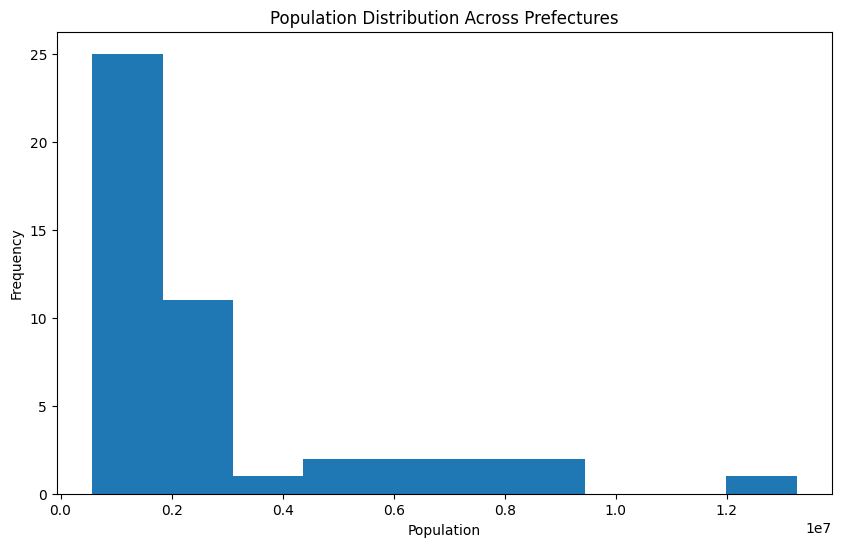

In [15]:
plt.figure(figsize=(10, 6))

plt.hist(df_grouped['Population'], bins=10)

plt.title("Population Distribution Across Prefectures")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

The histogram shows that a high frequency of prefectures fall within lower population ranges, while only a few prefectures belong to very large population ranges.

A few prefectures have extremely large populations, creating a long right tail in the distribution.

This confirms that the population distribution is right-skewed.

### Boxplot of Population Distribution

A boxplot helps visualize the spread of the data and identify potential outliers.

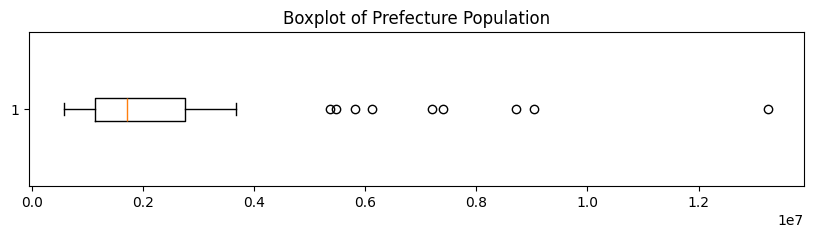

In [16]:
plt.figure(figsize=(10, 2))

plt.boxplot(df_grouped['Population'], vert=False)

plt.title("Boxplot of Prefecture Population")

plt.show()

The boxplot highlights several highly populated prefectures that appear as outliers.

Most prefectures are concentrated within a lower population range, while a few prefectures have significantly larger populations.

The long spread toward the right side confirms that the population distribution is right-skewed.

## Top 10 Most Populated Prefectures

This visualization highlights the prefectures with the highest populations in Japan.

In [17]:
top_10 = df_grouped.sort_values(by='Population', ascending=False).head(10)

top_10

,Prefecture,Population
39,Tokyo Prefecture,13257801
17,Kanagawa Prefecture,9043288
31,Osaka Prefecture,8713089
0,Aichi Prefecture,7401952
33,Saitama Prefecture,7206714
3,Chiba Prefecture,6126343
5,Fukui Prefecture,5815467
11,Hyogo Prefecture,5468729
10,Hokkaido,5357487
36,Shizuoka Prefecture,3674371


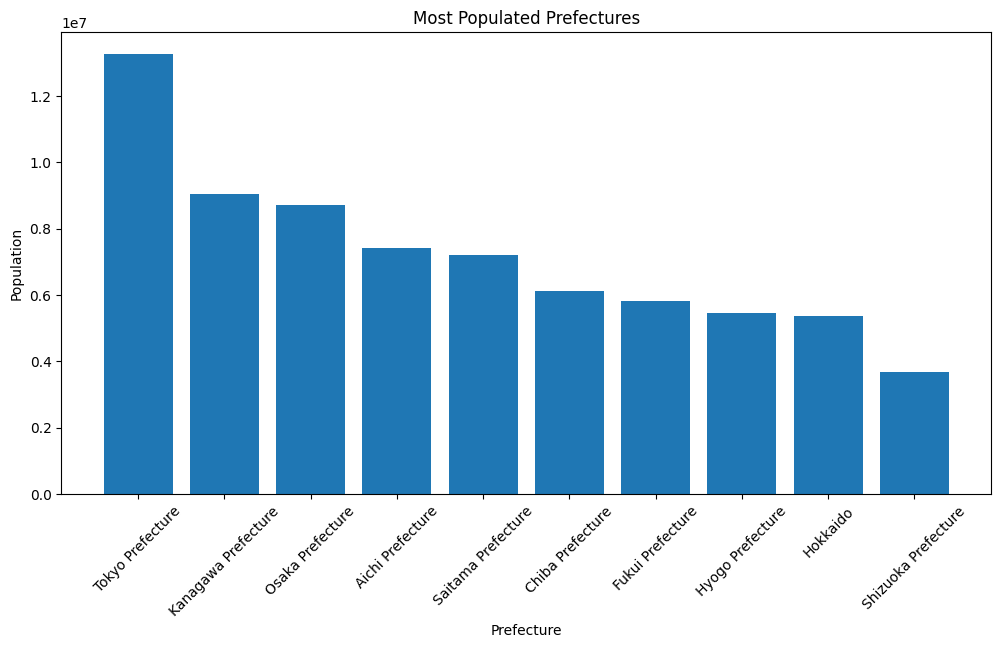

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(top_10['Prefecture'], top_10['Population'])

plt.title("Most Populated Prefectures")
plt.xlabel("Prefecture")
plt.ylabel("Population")

plt.xticks(rotation=45)

plt.show()

The bar chart shows that Tokyo Prefecture has the largest population among all prefectures in the dataset.

A noticeable gap exists between the most populated prefectures and the remaining regions, indicating that population distribution in Japan is concentrated heavily in a few urban areas.

This visualization further supports the earlier statistical findings of high spread and right-skewed distribution.

### Least Populated Prefectures

This visualization highlights prefectures with the smallest populations in the dataset.

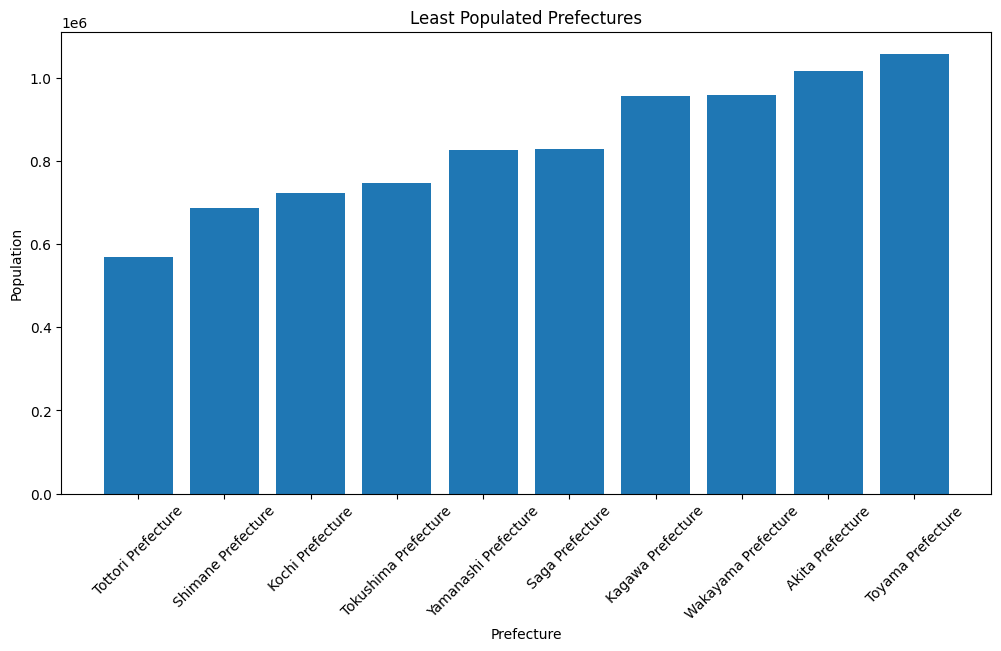

In [19]:
bottom_10 = df_grouped.sort_values(by='Population').head(10)

plt.figure(figsize=(12,6))

plt.bar(bottom_10['Prefecture'], bottom_10['Population'])

plt.title("Least Populated Prefectures")
plt.xlabel("Prefecture")
plt.ylabel("Population")

plt.xticks(rotation=45)

plt.show()

The chart shows that several prefectures such as Tottori and Shimane have significantly smaller populations compared to major urban prefectures such as Tokyo and Osaka.

This further highlights the uneven population distribution across Japan.

# Conclusion

This project explored population distribution across Japanese prefectures using statistical analysis and data visualization.

Key findings from the analysis include:
- Population distribution across prefectures is highly uneven.
- A few prefectures such as Tokyo, Kanagawa and Osaka contain significantly larger populations than most other prefectures.
- The histogram and boxplot showed a right-skewed distribution with several high-population outliers.
- Measures such as variance and standard deviation confirmed the large spread in population values.
- The median was lower than the mean, further supporting the presence of skewness in the dataset.

Through this project, statistical concepts such as central tendency, variability, and visualization techniques were applied to a real-world dataset using pandas and matplotlib.